# AB Testing for Eniac

## Imports

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import re
import math

#### Step 1: Defining Hypotheses:<br>
**Null Hypothesis:** All differences between webpage click through rates were simply due to the random sampling<br><br>
**Alternative Hypothesis:** Some differences between webpage click through rates were not due to the random sampling

#### Step 2: Setting alpha:

In [ ]:
alpha = 0.05

#### Step 3: Gathering data from csvs and arranging in contingency table:

In [ ]:
# Defining function for extracting data from csv
def get_clicks(version):
    page_df = pd.read_csv(f'../data/eniac_{version.lower()}.csv')
    page_info = page_df['Snapshot information'][1]
    # Extract num visits from snapshot info
    visits = re.findall(pattern='(\d+) visits', string=page_info)[0]
    num_visits = int(visits)
    # Find element being tested
    button = page_df['Name'].isin(['SEE DEALS', 'SHOP NOW'])
    # Get clicked and didn't click
    clicked = page_df.loc[button, 'No. clicks'].iloc[0]
    didnt_click = num_visits - clicked
    return clicked, didnt_click

versions = ['A', 'B', 'C', 'D']

# Setting up empty contingency table
observed = pd.DataFrame(
    columns=versions,
    index=['Clicked', 'Didn\'t Click']
)

# Looping through versions grabbing click and didn't click counts
for version in versions:
    observed[version] = get_clicks(version)

observed

,A,B,C,D
Clicked,512,281,527,193
Didn't Click,24814,24466,24349,25040


#### Step 4: Calculating Statistical Significance

In [ ]:
# Calculating statistical significance
chisq, pvalue, df, expected = chi2_contingency(observed)
# Comparing with threshold
pvalue < alpha

np.True_

In [ ]:
pvalue

np.float64(2.716121660786871e-48)

### Post-Hoc Testing

Post-hoc testing requires running a lot of tests. This increases our overall chance of getting type 1 errors, so to mitigate this we have to reduce our alpha during post-hoc testing. There are several strategies for this, but an easy one is to simply divide alpha by the number of tests being run:

In [ ]:
num_versions = len(versions)
# Getting a count of all the ways they could be paired
num_comparisons = math.comb(num_versions, 2)
# Dividing alpha by the number of comparisons
adjusted_alpha = alpha/num_comparisons

We don't just want to know which differences are statistically significant, we also want to know which versions are best. To figure this out, every time we see a statistically significant difference we'll have to calculate the click through rates for the versions to figure out which one is better. We can then eliminate the one we know is worse from the running. If we do this for all the comparisons we should end up with only the versions that have tied for first:

In [ ]:
# Calculating CTR for each version
ctrs = (observed / observed.sum()).iloc[0,:]
ctrs

A    0.020216
B    0.011355
C    0.021185
D    0.007649
Name: Clicked, dtype: float64

In [ ]:
# Set of all versions (to remove losers from)
contenders = set(versions)

# Looping through pairs and computing significance
for v1 in versions:
    for v2 in versions:

        # Running new chi2 test with each pair of versions
        pair_contingency_table = observed[[v1,v2]]
        chisq, pvalue, df, expected = chi2_contingency(pair_contingency_table)

        # If statistically significant, removing loser from contenders
        if pvalue < adjusted_alpha:
            # (we only need to check 1 direction because the loop will repeat the same pair with v1 and v2 swapped)
            if ctrs.loc[v1] > ctrs.loc[v2]:
                # Removing loser from contenders
                contenders -= set(v2)
contenders

{'A', 'C'}

Alternatively, if you want to avoid comparing A to B and then B to A, you can use this code which avoids repeated pairs. It's a little harder to read for beginners though which is why the above code is provided as well.

In [ ]:
contenders = set(versions)

# Looping through pairs and computing significance
for idx1 in range(num_versions-1): #(0, 1, 2)
    for idx2 in range(idx1+1, num_versions): #(1, 2, 3), (2, 3), (3)

        # Running new chi2 test with each pair of versions
        pair_contingency_table = observed.iloc[:, [idx1, idx2]]
        _, pvalue, _, _ = chi2_contingency(pair_contingency_table)

        # If statistically significant, removing loser from contenders
        if pvalue < adjusted_alpha:
            # Figuring out which is worse...
            loser = idx2 if ctrs.iloc[idx1] > ctrs.iloc[idx2] else idx1
            # and removing it from the contenders
            contenders -= set(versions[loser])

contenders

{'A', 'C'}

It looks like A and C are better than the others, but the comparison between the two of them was inconclusive. In this case we should lean toward sticking with version A. The whole reason we are being careful and checking statistical significance is so that we don't make changes to the website until we have good evidence that they will improve things. In this case the result is inconclusive whether version C could improve things so we should stick with version A.

However, before we make any conclusions, we should check the guardrail metrics to make sure the difference was not due to chance. We may even be able to break the tie if we see that one version has significantly better scores with these other metrics.

## Guardrail Metrics

As mentioned on the LMS, some additional guardrail metrics were collected which we should always check to make sure the primary metric, click-through-rate, isn't misleading. In addition to the ones on the LMS, you may have noticed that in the snapshot information there is a number for how many clicks in total were made on the webpage, which allows us to calculate the bounce rate as well. These guardrail metrics may also be able to help us decide between version A and C.

In [ ]:
guardrail_metrics = {}

If you knew you wanted to collect the bounce rate it would be easy to incorporate into the earlier code that was gathering the visits. Best practice would be to edit the code above to reduce redundancy, but for teaching purposes, to make this easier to follow, we will just repeat the process of looping through the snapshots down here, this time gathering the total clicks and calculating the bounce rate.

In [ ]:
# Function for fetching visits and clicks data to calculate ctr
def get_bounce_rate(version):
    page_df = pd.read_csv(f'../data/eniac_{version}.csv')
    page_info = page_df['Snapshot information'][1]
    visits = re.findall(pattern='(\d+) visits', string=page_info)[0]
    clicks = re.findall(pattern='(\d+) clicks', string=page_info)[0]
    bounce_rate = 1-(int(clicks)/int(visits))
    return bounce_rate

# Looping through versions and getting their bounce rates
guardrail_metrics['Bounce Rate'] = [get_bounce_rate(version) for version in versions]

There were graphs on the LMS with information about the Drop-Off and Homepage-Return rates. They didn't give you the numbers so here I've just approximated them by looking at the graphs

In [ ]:
# Manually estimated from graphs on LMS
guardrail_metrics['Drop-Off Rate'] = [0.098, None, 0.125, 0.122]
guardrail_metrics['Homepage-Return Rate'] = [0.0525, None, 0.047, 0.026]

In [ ]:
guardrail_metrics_df = pd.DataFrame(guardrail_metrics, index=versions)
guardrail_metrics_df

,Bounce Rate,Drop-Off Rate,Homepage-Return Rate
A,0.084972,0.098,0.0525
B,0.094557,NaN,NaN
C,0.074168,0.125,0.0470
D,0.098680,0.122,0.0260


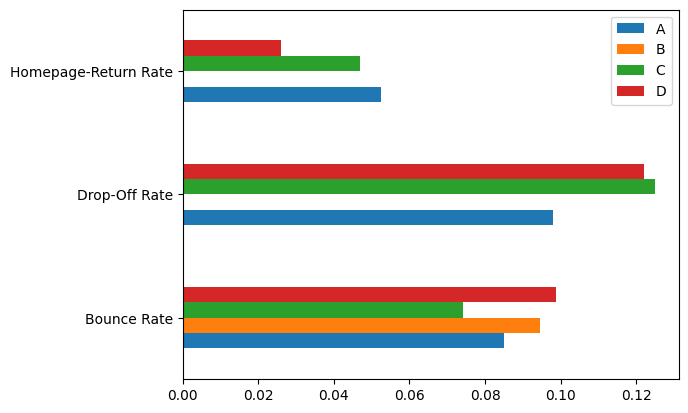

In [ ]:
# Plotting the guardrail scores (smaller numbers are better)
guardrail_metrics_df.T.plot.barh();

We could also include the primary metric to compare with all our KPIs

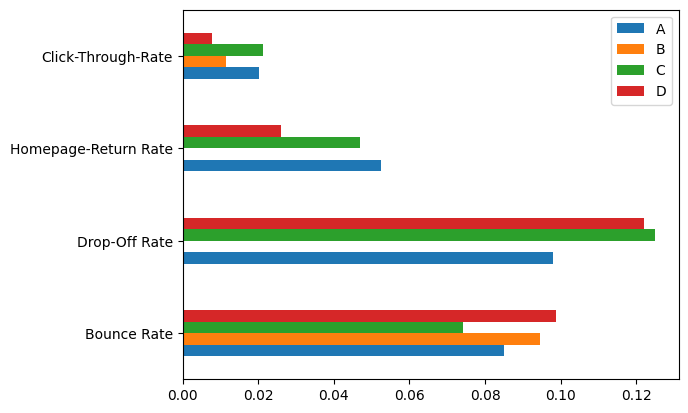

In [ ]:
# Plotting all metrics
all_metrics = guardrail_metrics_df.copy()
all_metrics['Click-Through-Rate'] = ctrs
all_metrics.T.plot.barh();

The guardrail metrics aren't showing any signs of the click-through-rate being misleading so we are good to trust the original results and stick with version A <br><br>
When it comes to tie-breaking, in this case, the differences between A and C with these guardrail metrics are not consistent enough to convince us to move from A to C. A has a better drop-off rate and C has slightly better homepage return and bounce rates. Altogether we don't have strong evidence that changing versions will improve UX. If we did want to use these metrics for tie-breaking though, we would need to check if the differences between A and C are statistically significant.

### BONUS: Calculating statistical significance of differences for guardrail metrics

Since we want to run tests for three guardrail metrics we should divide alpha by 3. <br>

By performing another set of tests we are adding more opportunities for type 1 errors, but generally since the click through rates (our primary performance metric) of these two versions have been found to be very similar, the consequences of making a type 1 error with these tie-breaking tests are much less severe.

In [ ]:
num_tests = 3
tie_break_alpha = alpha/num_tests

Right now we have the data as percentages (rates) so we'll need to use the number of visits to turn those rates into contingency tables that we can actually calculate the chi-squared for:

In [ ]:
# Pair guardrail metric column names with contingency table indexes (just for nice looking tables)
metrics = {
    'Bounce Rate': ['bounce', 'click'],
    'Drop-Off Rate': ['drop', "didn't drop"],
    'Homepage-Return Rate': ['return', "didn't return"]
}

# This dict will contain a contingency table for each metric
contingency_tables = {}

# Loop through each metric
for metric_name, index_labels in metrics.items():

    # Create an empty contingency table for this metric
    contingency_table = pd.DataFrame(
        columns=list(contenders),
        index=metrics[metric_name]
    )

    # Get the counts for A and C for this metric
    for version in contenders:

        # Convert rates to counts
        visits = observed[version].sum()
        rate = guardrail_metrics_df.loc[version, metric_name]
        did = int(rate * visits) #bounced, dropped off, or returned to homepage
        didnt = visits - did #remaining visitors did not bounce, drop off, or return to homepage

        # Add version's counts to metric's contingency table
        contingency_table[version] = [did, didnt]

    # Add contingency table to dictionary of tables
    contingency_tables[metric_name] = contingency_table

# Display contingency tables from dict
display(contingency_tables['Bounce Rate'])
display(contingency_tables['Drop-Off Rate'])
display(contingency_tables['Homepage-Return Rate'])

,A,C
bounce,2151,1845
click,23175,23031


,A,C
drop,2481,3109
didn't drop,22845,21767


,A,C
return,1329,1169
didn't return,23997,23707


Now we can calculate the statistical significance for these metrics

In [ ]:
for metric in contingency_tables:

    # Calculating significance
    chisq, pvalue, df, expected = chi2_contingency(contingency_tables[metric])

    if pvalue < tie_break_alpha:
        # Finding version with lower rate (better)
        better = guardrail_metrics_df[metric].idxmin()
        print(f'Version {better.upper()} has a statistically significantly better {metric}')
    else:
        print(f'The test was inconclusive. The difference in {metric} may be due to chance.')

Version C has a statistically significantly better Bounce Rate
Version A has a statistically significantly better Drop-Off Rate
Version D has a statistically significantly better Homepage-Return Rate


It looks like all of the differences that we can see visually in the bar graph were statistically significant.